# Fig 3 Kymo — kymographs vs the diffusion ratio

Loads the runs produced by `20260728_run_fig3kymo.py` (`20260728_fig3kymo_data.npz`)
and redraws the biomass kymographs of one single-influx community at each
byproduct/influx diffusion ratio `p = D_byprod/D_ext`, once with a linear time
axis and once logarithmic.

Nothing is integrated here and no project module is imported: the npz holds the
recorded fields, so the plotting is inline and easy to edit. Pick which `p` to
show at the top of the drawing cell; figures are written into `Panels/`.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import palettable as pal

sns.set_context('talk', rc={'font.size': 15, 'axes.titlesize': 15, 'axes.labelsize': 15})
sns.set_style('whitegrid', {'grid.color': '.9', 'grid.linestyle': '--',
                            'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

# Biomass colour scale (edit to taste).
BIOMASS_CMAP = pal.colorbrewer.sequential.YlGn_9.mpl_colormap

In [2]:
# Load the runs and index them by diffusion ratio.
HERE = pathlib.Path.cwd()
PANELS = HERE / 'Panels'
data = np.load(HERE / '20260728_fig3kymo_data.npz')

ps = data['p']
t = data['t']                  # (n_times,) recording grid, shared by every run

# by_p[p] -> everything needed to draw that run.
by_p = {float(p): {'x': data['x'][i], 'biomass': data['biomass'][i],
                   'k_star': float(data['k_star'][i]), 'L_box': float(data['L_box'][i]),
                   'max_mrl': float(data['max_mrl'][i]), 'done': bool(data['done'][i])}
        for i, p in enumerate(ps)}

print(f"{len(t)} recording times to t = {float(data['t_max']):g}, "
      f"{int(data['ssize'])} grid cells, box sized for {float(data['n_peaks']):g} peaks")
print(f"community: {int(data['n_survivors'])} of {int(data['Ns'])} strains survive")
print('available p values:', sorted(by_p))

599 recording times to t = 1e+06, 1024 grid cells, box sized for 20 peaks
community: 2 of 10 strains survive
available p values: [0.01, 0.1, 1.0]


In [ ]:
def plot_kymograph(ax, run, log_time=False, cmap=BIOMASS_CMAP):
    """Draw one run's total biomass against position and time.

    On a log time axis the t = 0 row has no place, so it is dropped along with
    any rows the solver never reached (stored as NaN). The mesh is rasterised so
    the svg stays small while axes and text stay vector.
    """
    biomass = run['biomass']
    keep = ~np.all(np.isnan(biomass), axis=1)
    if log_time:
        keep &= t > 0

    im = ax.pcolormesh(run['x'], t[keep], biomass[keep], cmap=cmap,
                       shading='auto', rasterized=True)
    if log_time:
        ax.set_yscale('log')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$t$')
    return im

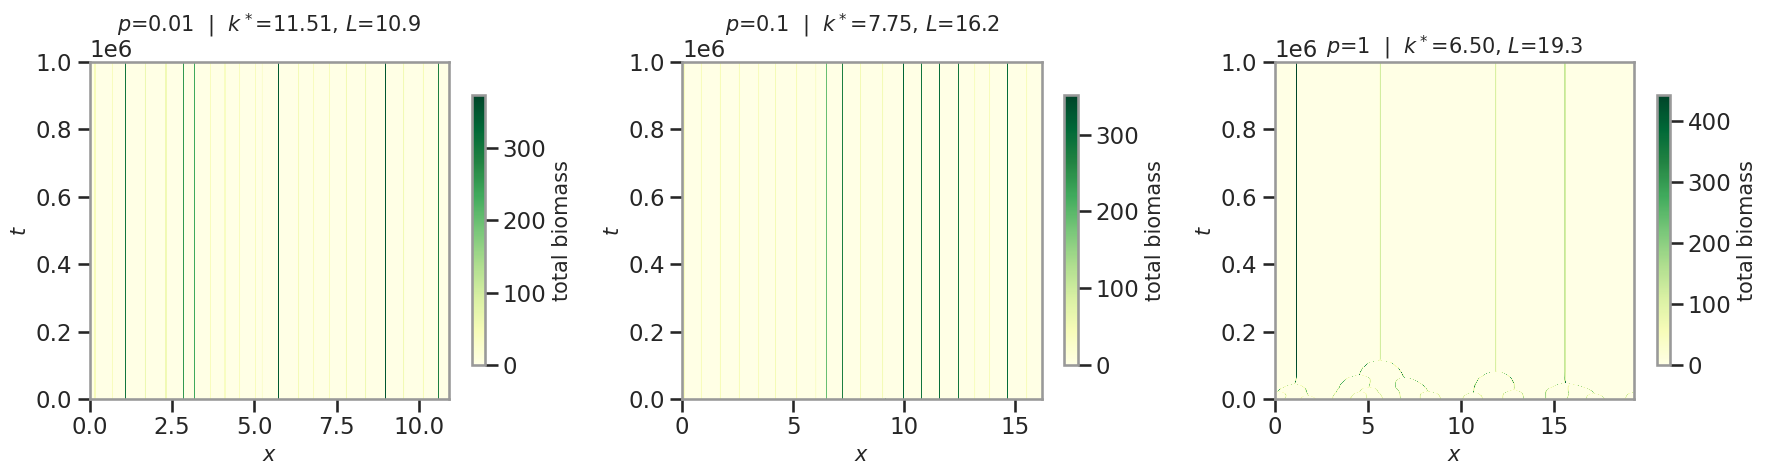

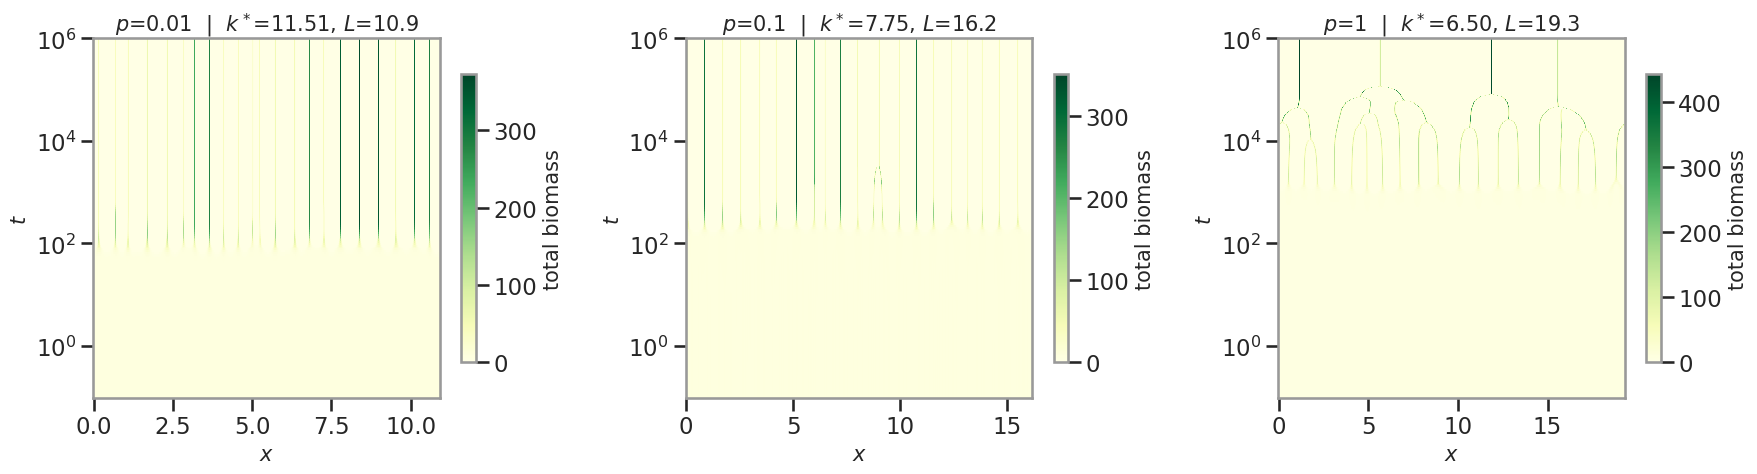

In [4]:
# Choose which p values to plot (any subset of the available ones).
plot_ps = sorted(by_p)                       # e.g. [0.01, 1.0]

for log_time, name in ((False, 'linear'), (True, 'log')):
    fig, axes = plt.subplots(1, len(plot_ps), figsize=(6.0 * len(plot_ps), 5.0),
                             squeeze=False)
    for ax, p in zip(axes[0], plot_ps):
        run = by_p[p]
        im = plot_kymograph(ax, run, log_time=log_time)
        ax.set_title(f"$p$={p:g}  |  $k^*$={run['k_star']:.2f}, $L$={run['L_box']:.1f}")
        fig.colorbar(im, ax=ax, shrink=0.8, label='total biomass')
        # # Where the box would sit if the pattern kept its linear wavelength.
        # ax.set_xlim(0, run['L_box'])

    fig.tight_layout()
    fig.savefig(PANELS / f'20260728_fig3kymo_replot_{name}.svg', bbox_inches='tight')
    plt.show()

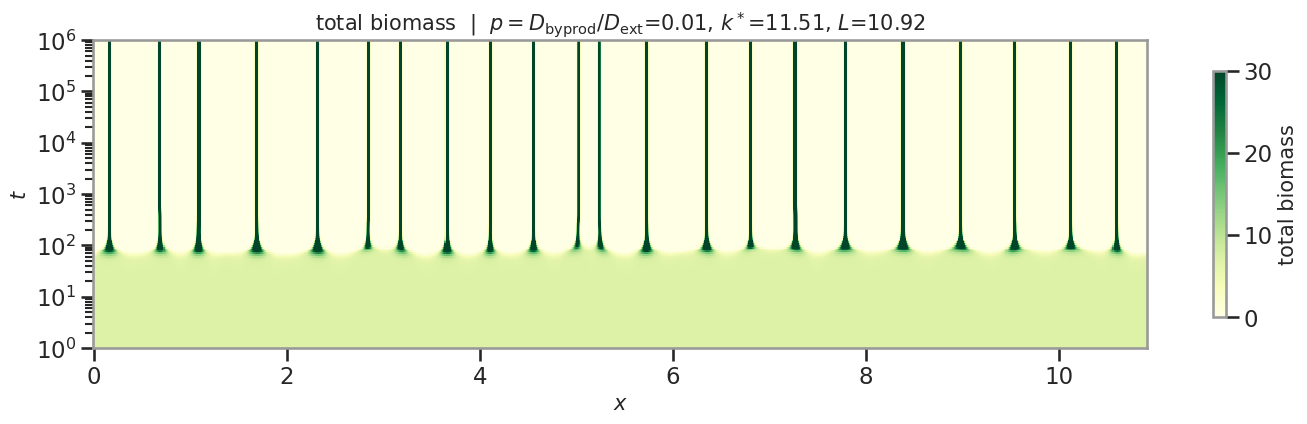

In [36]:
# One ratio on its own, at figure size.
p = 0.01

run = by_p[p]
fig, ax = plt.subplots(figsize=(17, 4))
# im = plot_kymograph(ax, run, log_time=True)

log_time = True

biomass = run['biomass']
keep = ~np.all(np.isnan(biomass), axis=1)
cmap=BIOMASS_CMAP

im = ax.pcolormesh(run['x'], t[keep], biomass[keep], cmap=cmap, shading='auto', rasterized=True, clim=(0, 30))

ax.set_ylim(1e-0,1e6)
ax.set_yscale('log')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')

ax.set_title(f"total biomass  |  $p=D_{{\\rm byprod}}/D_{{\\rm ext}}$={p:g}, "
             f"$k^*$={run['k_star']:.2f}, $L$={run['L_box']:.2f}")

fig.colorbar(im, ax=ax, shrink=0.8, label='total biomass')
fig.savefig(PANELS / f'20260728_fig3kymo_replot_p{p:g}_log.svg', bbox_inches='tight')
plt.show()

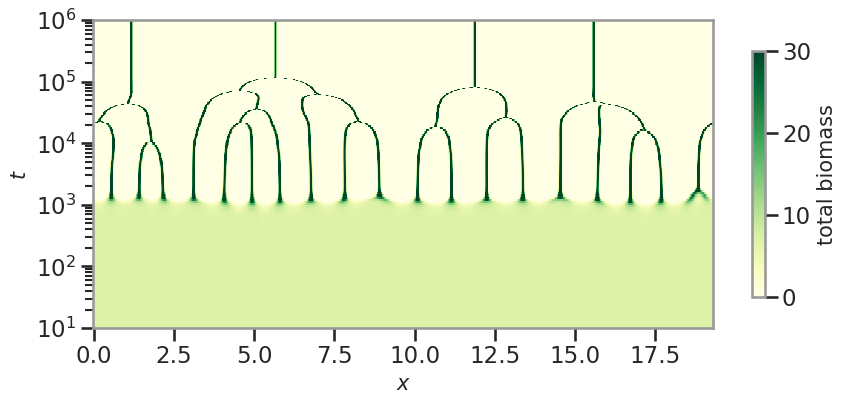

In [33]:
# One ratio on its own, at figure size.
p = 1

run = by_p[p]
fig, ax = plt.subplots(figsize=(10, 4))
# im = plot_kymograph(ax, run, log_time=True)

log_time = True

biomass = run['biomass']
keep = ~np.all(np.isnan(biomass), axis=1)
cmap=BIOMASS_CMAP

im = ax.pcolormesh(run['x'], t[keep], biomass[keep], cmap=cmap, shading='auto', rasterized=True, clim=(0, 30))

ax.set_ylim(1e1,1e6)
ax.set_yscale('log')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')

# ax.set_title(f"total biomass  |  $p=D_{{\\rm byprod}}/D_{{\\rm ext}}$={p:g}, "
#              f"$k^*$={run['k_star']:.2f}, $L$={run['L_box']:.2f}")

fig.colorbar(im, ax=ax, shrink=0.8, label='total biomass')
fig.savefig(PANELS / f'20260728_fig3kymo_replot_p{p:g}_log.svg', bbox_inches='tight')
plt.show()

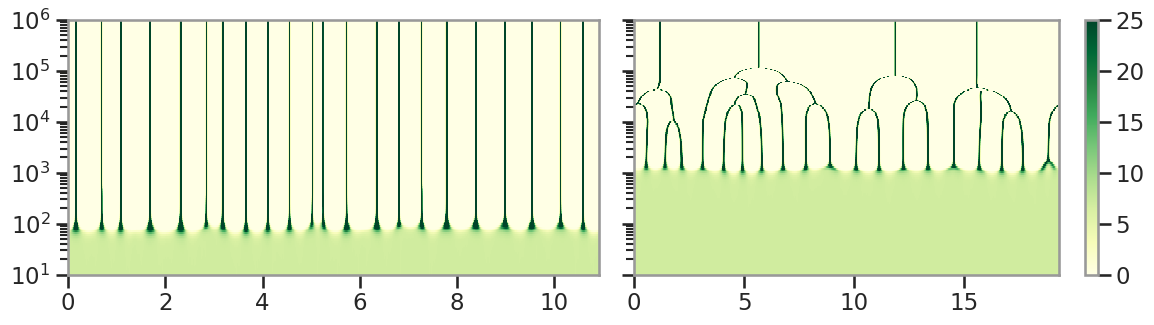

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

for p,ax in zip([0.01, 1], axs):
    run = by_p[p]
    # im = plot_kymograph(ax, run, log_time=True)

    log_time = True

    biomass = run['biomass']
    keep = ~np.all(np.isnan(biomass), axis=1)
    cmap=BIOMASS_CMAP

    im = ax.pcolormesh(run['x'], t[keep], biomass[keep], cmap=cmap, shading='auto', rasterized=True, clim=(0, 25))

    ax.set_ylim(1e1,1e6)
    # ax.set_xlim(0,10)
    ax.set_yscale('log')
    ax.set_yticks([1e1, 1e2, 1e3, 1e4, 1e5, 1e6])

    # ax.set_xlabel('$x$')
    # ax.set_ylabel('$t$')

fig.colorbar(im, ax=ax, shrink=1)
plt.tight_layout()
plt.savefig(PANELS / f'20260728_fig3kymo_replot_p0.01_1_log.svg', bbox_inches='tight')